# AI광고 vs 인간광고 분류 CNN - 풀방 버전
3단계 학습 + Mixup + TTA + 5-Fold CV + 전체 데이터셋 평가

In [22]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

GPU: Tesla T4


In [23]:
!git clone https://github.com/editpanda-dev/CNN_AIM.git
%cd CNN_AIM

Cloning into 'CNN_AIM'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 255 (delta 4), reused 7 (delta 2), pack-reused 246 (from 1)
Receiving objects: 100% (255/255), 105.83 MiB | 28.36 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/CNN_AIM/CNN_AIM/CNN_AIM


In [24]:
import os, random, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split, StratifiedKFold
from PIL import Image
import copy

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DATA_DIR    = '광고_최종'
CLASS_NAMES = ['인간광고', 'AI광고']
IMG_SIZE    = 224
BATCH_SIZE  = 32
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH   = 'best_model.pth'
print(f'Device: {DEVICE}')

Device: cuda


In [25]:
# ── 데이터 로드 ────────────────────────────────────────
def collect_paths(data_dir, class_names):
    EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}
    paths, labels = [], []
    for label, cls in enumerate(class_names):
        for f in os.listdir(os.path.join(data_dir, cls)):
            if os.path.splitext(f)[1].lower() in EXTS:
                paths.append(os.path.join(data_dir, cls, f))
                labels.append(label)
    return paths, labels

class AdDataset(Dataset):
    def __init__(self, paths, labels, tf): self.paths,self.labels,self.tf=paths,labels,tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.tf(img), self.labels[i]

MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE+48, IMG_SIZE+48)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.4,contrast=0.4,saturation=0.4,hue=0.15),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
    transforms.RandomErasing(p=0.3,scale=(0.02,0.2)),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])
# TTA용 augmentation 여러 버전
tta_tfs = [
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE+32,IMG_SIZE+32)), transforms.CenterCrop(IMG_SIZE), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ColorJitter(brightness=0.1,contrast=0.1), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomRotation(10), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
]

all_paths, all_labels = collect_paths(DATA_DIR, CLASS_NAMES)
all_labels_np = np.array(all_labels)
print(f'전체: {len(all_paths)}장 (인간:{all_labels.count(0)}, AI:{all_labels.count(1)})')

전체: 239장 (인간:115, AI:124)


In [26]:
# ── 모델 ──────────────────────────────────────────────
def build_model():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_f, 256),
        nn.SiLU(),
        nn.Dropout(0.25),
        nn.Linear(256, 2),
    )
    return m

def set_trainable(model, mode):
    """mode: 'head' | 'partial' | 'full'"""
    for p in model.parameters(): p.requires_grad = False
    if mode == 'head':
        for p in model.classifier.parameters(): p.requires_grad = True
    elif mode == 'partial':
        for n,p in model.named_parameters():
            if any(f'features.{i}' in n for i in [5,6,7,8]) or 'classifier' in n:
                p.requires_grad = True
    else:  # full
        for p in model.parameters(): p.requires_grad = True

# Mixup
def mixup(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam

def mixup_loss(crit, pred, ya, yb, lam):
    return lam*crit(pred,ya)+(1-lam)*crit(pred,yb)

def run_epoch(model, loader, crit, opt=None, use_mixup=False):
    is_train = opt is not None
    model.train() if is_train else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for imgs,labels in loader:
            imgs,labels = imgs.to(DEVICE), labels.to(DEVICE)
            if is_train and use_mixup:
                imgs,ya,yb,lam = mixup(imgs,labels)
                out = model(imgs)
                loss = mixup_loss(crit,out,ya,yb,lam)
            else:
                out = model(imgs)
                loss = crit(out,labels)
            if is_train:
                opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item()*imgs.size(0)
            correct += (out.argmax(1)==labels).sum().item()
            total += imgs.size(0)
    return loss_sum/total, correct/total

In [27]:
# ── TTA 예측 ──────────────────────────────────────────
def predict_tta(model, img_path):
    model.eval()
    img = Image.open(img_path).convert('RGB')
    probs = torch.zeros(2).to(DEVICE)
    with torch.no_grad():
        for tf in tta_tfs:
            t = tf(img).unsqueeze(0).to(DEVICE)
            probs += torch.softmax(model(t)[0], 0)
    return probs / len(tta_tfs)

def eval_tta(model, paths, labels):
    correct = 0
    for p, l in zip(paths, labels):
        pred = predict_tta(model, p).argmax().item()
        if pred == l: correct += 1
    return correct / len(labels)

In [28]:
# ── 3단계 학습 함수 ─────────────────────────────────────
def train_3phase(tr_paths, tr_labels, val_paths, val_labels, verbose=True):
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    model = build_model().to(DEVICE)

    # 샘플러
    cc = [tr_labels.count(i) for i in range(2)]
    sw = [1.0/cc[l] for l in tr_labels]
    sampler = WeightedRandomSampler(sw, len(tr_labels), replacement=True)
    tr_dl  = DataLoader(AdDataset(tr_paths, tr_labels, train_tf), BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
    val_dl = DataLoader(AdDataset(val_paths, val_labels, val_tf), BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    best_acc, best_state = 0.0, None

    phases = [
        ('head',    'head',    10, 1e-3,  1e-3,  False),
        ('partial', 'partial', 30, 5e-4,  1e-3,  True),
        ('full',    'full',    20, 5e-5,  5e-4,  True),
    ]

    for pname, mode, epochs, lr, wd, use_mix in phases:
        set_trainable(model, mode)
        params = filter(lambda p: p.requires_grad, model.parameters())
        opt = optim.AdamW(params, lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr/20)
        no_imp, pat = 0, 10
        if verbose: print(f'\n--- Phase {pname} ({epochs} epochs, mixup={use_mix}) ---')
        for ep in range(1, epochs+1):
            tl,ta = run_epoch(model, tr_dl, crit, opt, use_mix)
            vl,va = run_epoch(model, val_dl, crit, None, False)
            sch.step()
            mk=''
            if va > best_acc:
                best_acc=va; best_state=copy.deepcopy(model.state_dict()); mk='  ← best'; no_imp=0
            else: no_imp+=1
            if verbose: print(f'  [{ep:02d}/{epochs}] train={ta:.4f} | val={va:.4f}{mk}')
            if no_imp>=pat:
                if verbose: print(f'  Early stop')
                break

    model.load_state_dict(best_state)
    return model, best_acc

In [29]:
# ── 5-Fold Cross Validation ────────────────────────────
print('=== 5-Fold Cross Validation ===')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_accs, fold_tta_accs = [], []
best_global_model, best_global_acc = None, 0.0

for fold, (tr_idx, val_idx) in enumerate(skf.split(all_paths, all_labels_np), 1):
    print(f'\n====== Fold {fold}/5 ======')
    tr_p  = [all_paths[i] for i in tr_idx]
    val_p = [all_paths[i] for i in val_idx]
    tr_l  = [all_labels[i] for i in tr_idx]
    val_l = [all_labels[i] for i in val_idx]

    model, best_acc = train_3phase(tr_p, tr_l, val_p, val_l, verbose=True)

    # TTA 평가
    tta_acc = eval_tta(model, val_p, val_l)
    fold_accs.append(best_acc)
    fold_tta_accs.append(tta_acc)
    print(f'  Fold {fold} → val={best_acc:.4f} | TTA val={tta_acc:.4f}')

    if tta_acc > best_global_acc:
        best_global_acc = tta_acc
        torch.save(model.state_dict(), SAVE_PATH)
        best_global_model = copy.deepcopy(model)

print(f'\n=== 5-Fold 결과 ===')
for i,(a,t) in enumerate(zip(fold_accs,fold_tta_accs),1):
    print(f'  Fold {i}: val={a:.4f}  TTA={t:.4f}')
print(f'  평균 val acc : {np.mean(fold_accs)*100:.1f}%')
print(f'  평균 TTA acc : {np.mean(fold_tta_accs)*100:.1f}%')

=== 5-Fold Cross Validation ===

====== Fold 1/5 ======

--- Phase head (10 epochs, mixup=False) ---
  [01/10] train=0.5602 | val=0.4792  ← best
  [02/10] train=0.5550 | val=0.5625  ← best
  [03/10] train=0.6702 | val=0.6458  ← best
  [04/10] train=0.6649 | val=0.6250
  [05/10] train=0.7644 | val=0.6875  ← best
  [06/10] train=0.7382 | val=0.6042
  [07/10] train=0.6859 | val=0.6042
  [08/10] train=0.6649 | val=0.6250
  [09/10] train=0.6702 | val=0.6250
  [10/10] train=0.6545 | val=0.6042

--- Phase partial (30 epochs, mixup=True) ---
  [01/30] train=0.5340 | val=0.6667
  [02/30] train=0.6073 | val=0.6042
  [03/30] train=0.6597 | val=0.5000
  [04/30] train=0.5969 | val=0.5417
  [05/30] train=0.6073 | val=0.6042
  [06/30] train=0.6545 | val=0.6042
  [07/30] train=0.8482 | val=0.6458
  [08/30] train=0.6649 | val=0.6667
  [09/30] train=0.7330 | val=0.6458
  [10/30] train=0.8010 | val=0.5833
  Early stop

--- Phase full (20 epochs, mixup=True) ---
  [01/20] train=0.7225 | val=0.6042
  [02/2

In [30]:
# ── 전체 데이터셋으로 최종 학습 + 전체 평가 ────────────────
print('\n=== 전체 데이터셋으로 최종 학습 ===')
# train/val 비율 없이 전체로 학습 (최종 모델용)
# val 고정: 마지막 20%를 평가용으로만 사용 (학습엔 안 씀)
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=SEED, stratify=all_labels)

final_model, final_acc = train_3phase(tr_paths, tr_labels, val_paths, val_labels, verbose=True)

# 전체 239장 TTA 평가
print('\n전체 데이터셋 TTA 정확도 계산 중...')
full_acc = eval_tta(final_model, all_paths, all_labels)
print(f'전체 {len(all_paths)}장 TTA 정확도: {full_acc*100:.1f}%')

# 더 좋으면 저장
if full_acc > best_global_acc:
    torch.save(final_model.state_dict(), SAVE_PATH)
    print(f'최고 모델 갱신! {SAVE_PATH} 저장')

print(f'\n최종 요약')
print(f'  5-Fold 평균 TTA : {np.mean(fold_tta_accs)*100:.1f}%')
print(f'  전체 데이터 TTA : {full_acc*100:.1f}%')
print(f'  모델 저장 경로  : {SAVE_PATH}')


=== 전체 데이터셋으로 최종 학습 ===

--- Phase head (10 epochs, mixup=False) ---
  [01/10] train=0.4869 | val=0.4167  ← best
  [02/10] train=0.5864 | val=0.4167
  [03/10] train=0.6178 | val=0.3958
  [04/10] train=0.6230 | val=0.4792  ← best
  [05/10] train=0.6440 | val=0.4167
  [06/10] train=0.7173 | val=0.4375
  [07/10] train=0.6754 | val=0.4167
  [08/10] train=0.6859 | val=0.4792
  [09/10] train=0.7068 | val=0.5000  ← best
  [10/10] train=0.7277 | val=0.5000

--- Phase partial (30 epochs, mixup=True) ---
  [01/30] train=0.6597 | val=0.4583
  [02/30] train=0.6440 | val=0.5833  ← best
  [03/30] train=0.6649 | val=0.5417
  [04/30] train=0.6702 | val=0.5417
  [05/30] train=0.6335 | val=0.6458  ← best
  [06/30] train=0.7382 | val=0.6042
  [07/30] train=0.4974 | val=0.6042
  [08/30] train=0.6911 | val=0.6458
  [09/30] train=0.7330 | val=0.6250
  [10/30] train=0.7068 | val=0.6875  ← best
  [11/30] train=0.7592 | val=0.7292  ← best
  [12/30] train=0.6963 | val=0.6042
  [13/30] train=0.6649 | val=0.6042

              precision    recall  f1-score   support

        인간광고       0.96      0.95      0.95       115
        AI광고       0.95      0.96      0.96       124

    accuracy                           0.95       239
   macro avg       0.95      0.95      0.95       239
weighted avg       0.95      0.95      0.95       239



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_2852/3137827639.py:23: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2852/3137827639.py:23: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2852/3137

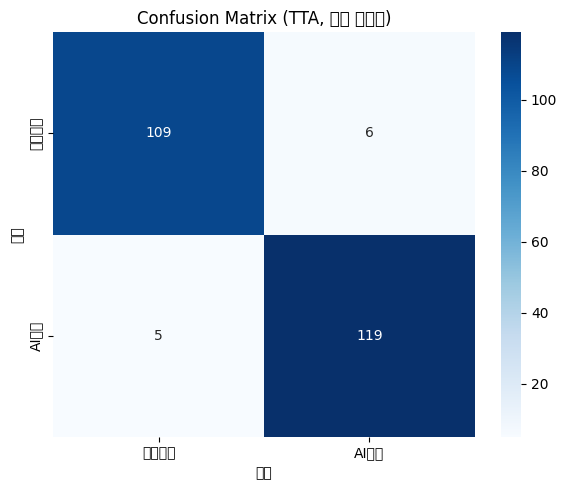

In [31]:
# ── 혼동행렬 시각화 ────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

model = build_model().to(DEVICE)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

preds, gts = [], []
for p, l in zip(all_paths, all_labels):
    pred = predict_tta(model, p).argmax().item()
    preds.append(pred); gts.append(l)

cm = confusion_matrix(gts, preds)
print(classification_report(gts, preds, target_names=CLASS_NAMES))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (TTA, 전체 데이터)')
plt.ylabel('실제'); plt.xlabel('예측')
plt.tight_layout(); plt.show()